# Un centavo de R en Python

+ Sesiones pasadas ya hemos tirado líneas de Python en Posit Cloud que es el espacio de nube clásico para correr R.

+ Lo "complicado" era hacer las configuraciones del enviroment, porque Python es quisquilloso con eso.

+ OJO: En Posit Cloud está instalado tanto R como Python, aunque el producto estrella es RStudio que está pensado para R.

+ En este pequeño notebook vamos a tirar líneas de R en Python, aunque en realidad la magia es de Google Colab

In [1]:
import pandas as pd

+ **MUY IMPORTANTE:** Google Colab ya trae instalado R!!!!

+ En realidad lo que haremos es decirle a Google Colab que algunos chunks serán de R

In [2]:
# Se utiliza la extension rpy2
%load_ext rpy2.ipython

+ Para tirar código R en un chunk de Colab simplemente hay que poner %%R hasta arriba del chunk

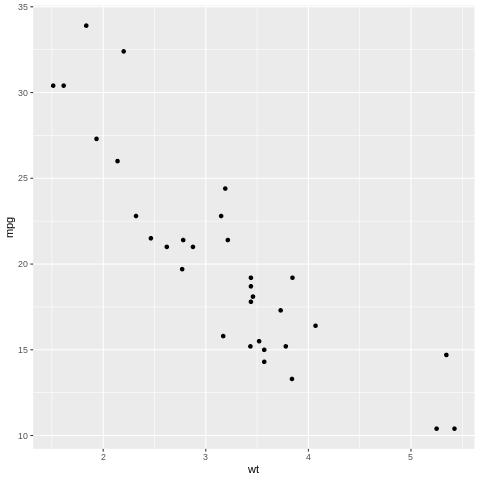

In [3]:
%%R
# A partir de aquí es sintaxis R
library(ggplot2)
# Estoy usando el dataset mtcars de R
# Estoy usando funciones de R
ggplot(mtcars, aes(x=wt, y=mpg)) + geom_point()

+ Por supuesto todos los objetos que se definen en chunks de R se pueden comunicar, i.e. no necesita estar todo en un solo chunk

In [4]:
%%R
# Creamos un vector de R en este chunk
mi_vector_en_r <- c(10, 20, 30, 40, 50)
mi_vector_en_r

[1] 10 20 30 40 50


In [5]:
%%R
# En este siguiente chunk voy a usar un objeto de R que ya estaba definido con anterioridad
mi_promedio <- mean(mi_vector_en_r)
mi_promedio

[1] 30


+ Pero lo importante no es tirar código de R y de Python por separado. La idea es que los objetos de R convivan e interactúen con los de Python y viceversa

In [6]:
# Acá estoy definiendo un pandas dataframe (de Python)
df = pd.DataFrame({
    'x': [1, 2, 3, 4, 5],
    'y': [10, 15, 13, 17, 20]
})
df

,x,y
0,1,10
1,2,15
2,3,13
3,4,17
4,5,20


+ Para decir a R que va a recibir un objeto de Python tengo que agregar el argumento `-i` junto a %%R del chunk y el objeto que voy a llevar hacia R.
+ Ese símbolillo `-i` viene de la palabra input

+ Ya existe el objeto df de Python

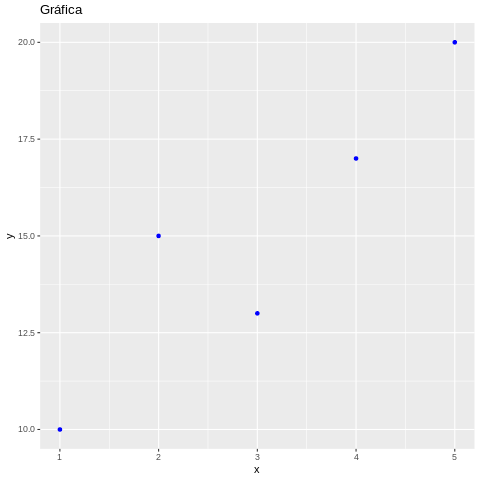

In [7]:
%%R -i df
#library(ggplot2)
# Tomo este dataframe de Python y lo utilizó como si fuera dataframe de R
ggplot(df, aes(x=x, y=y)) +
geom_point(color="blue") +
ggtitle("Gráfica")

+ Por supuesto, también podemos hacer lo contrario

+ Es decir, crear un objeto de R y pasarlo a Python para que lo use

+ Esto se hace con el argumento `-o` (que viene de la palabra OUTPUT)

In [8]:
%%R -o cachito_del_mtcars
# El objeto que se llama cachito_del_mtcars es lo que enviaré a Python
# Con sintaxis R, estoy obteniendo un subconjunto del mtcars y creándole una nueva columna
cachito_del_mtcars <- mtcars |> dplyr::filter(hp > 100) |> dplyr::mutate(hp_per_cyl = hp / cyl)
cachito_del_mtcars

                     mpg cyl  disp  hp drat    wt  qsec vs am gear carb
Mazda RX4           21.0   6 160.0 110 3.90 2.620 16.46  0  1    4    4
Mazda RX4 Wag       21.0   6 160.0 110 3.90 2.875 17.02  0  1    4    4
Hornet 4 Drive      21.4   6 258.0 110 3.08 3.215 19.44  1  0    3    1
Hornet Sportabout   18.7   8 360.0 175 3.15 3.440 17.02  0  0    3    2
Valiant             18.1   6 225.0 105 2.76 3.460 20.22  1  0    3    1
Duster 360          14.3   8 360.0 245 3.21 3.570 15.84  0  0    3    4
Merc 280            19.2   6 167.6 123 3.92 3.440 18.30  1  0    4    4
Merc 280C           17.8   6 167.6 123 3.92 3.440 18.90  1  0    4    4
Merc 450SE          16.4   8 275.8 180 3.07 4.070 17.40  0  0    3    3
Merc 450SL          17.3   8 275.8 180 3.07 3.730 17.60  0  0    3    3
Merc 450SLC         15.2   8 275.8 180 3.07 3.780 18.00  0  0    3    3
Cadillac Fleetwood  10.4   8 472.0 205 2.93 5.250 17.98  0  0    3    4
Lincoln Continental 10.4   8 460.0 215 3.00 5.424 17.82  0  0   

+ Nótese que este código es como si estuviéramos corriedo R en la consolo básico

+ Perdimos las ventajas de RStudio

In [9]:
type(cachito_del_mtcars)

pandas.core.frame.DataFrame

+ cachito_del_mtcars ahora es un objeto de Python

+ Aquí ya aparece un inconveniente ¿Cuál es?

+ Hay un objeto cachito_del_mtcars en R y hay un objeto cachito_del_mtcars en Python... eso significa que estoy ocupando en memoria espacio para los dos objetos.

+ Si mi compu es fragilona, no siempre va a aguantar esa carga.

+ Como buen dataframe de Python, puedo operarlo

In [10]:
# Chunk vainilla de Python
cachito_del_mtcars[['mpg', 'disp', 'hp']]

,mpg,disp,hp
Mazda RX4,21.0,160.0,110.0
Mazda RX4 Wag,21.0,160.0,110.0
Hornet 4 Drive,21.4,258.0,110.0
Hornet Sportabout,18.7,360.0,175.0
Valiant,18.1,225.0,105.0
Duster 360,14.3,360.0,245.0
Merc 280,19.2,167.6,123.0
Merc 280C,17.8,167.6,123.0
Merc 450SE,16.4,275.8,180.0
Merc 450SL,17.3,275.8,180.0


+ No sólo podemos pasar dataframes podemos pasar una amplia gama de objetos... Al menos los básicos que vimos, sí

In [12]:
# Voy a definir una lista en python
# y lo voy a mandar a R
py_lista = [10, 20, 30, 40, 50]
py_lista

[10, 20, 30, 40, 50]

In [13]:
%%R -i py_lista
# voy a operar lo que recibí de Python
nuevo_vector <- py_lista * 2
nuevo_vector

[1]  20  40  60  80 100


In [14]:
%%R
# Qué tipo de objeto es este?
class(nuevo_vector)

[1] "array"


+ Esta raro que pasemos de una lista de Python a un array de R.

+ Quizá sería un poquito más natural, tener un vector de R

In [15]:
%%R
# Estoy convirtiéndolo de array de R a vector de R
nuevo_vector <- as.vector(nuevo_vector)
class(nuevo_vector)

[1] "numeric"


+ También podemos hacer la operación de regreso

+ Voy a crear el objeto `r_vector` en R y lo pasaré a Python

In [17]:
%%R -o r_vector

r_vector <- c("Apple", "Banana", "Cherry")
r_vector

[1] "Apple"  "Banana" "Cherry"


In [18]:
# En python de qué clase es este objeto
type(r_vector)

numpy.ndarray

+ Ohhh!! Es un numpy array

In [19]:
# Lo quiero convertir en una lista de python
# con sintaxis python
mejor_quiero_una_lista = r_vector.tolist()
type(mejor_quiero_una_lista)

list

In [ ]:
mejor_quiero_una_lista

+ No todo es "miel sobre hojuelas."
+ Hasta el momento hemos utilizado 2 entornos de nube, muy bien configurados: Posit Cloud y Google Colab
+ Posit y Google ya nos ayudaron a configurar para que toda esta comunicación funcione bien.
+ Para hacerlo en local. Tengo tener instalado R y Python y después hacer algunas configuraciones no triviales
+ Otro problema es que no podemos instalar toda de librería de R en Colab. Hay librerías que son quisquillosas para ser instaladas fuera de R nativo.
+ Y viceversa, no toda librería de Python la podemos instalar en Posit Cloud